## **Student Depression Dataset**



> CRISP-DM Framework

> 1.   Business Understanding
> 2.   Data Understanding
> 3. Data Preparation
> 4. Modeling
> 5. Evaluation
> 6. Deployment














# 1. Business Understanding



> Goal: Predict whether a student is depressed



> Dataset: https://www.kaggle.com/datasets/adilshamim8/student-depression-dataset




# 2. Data Understanding

Import libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report,  roc_auc_score, roc_curve, auc, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier


Data Overview

In [8]:
# Load Dataset
df = pd.read_csv('/content/student_depression_dataset.csv')

In [9]:
# Display shape and first few rows
print("Shape:", df.shape)
df.head()

Shape: (27901, 18)


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [11]:
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,1.000000


# 3. Data Preparation

In [12]:
# Check missing values
print(df.isnull().sum())

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64


In [13]:
# Drop the 'id' column
df = df.drop(columns=['id'])

In [18]:
for i in df.columns:
  print(df[i].value_counts())

Gender
Male      15547
Female    12354
Name: count, dtype: int64
Age
24.0    2258
20.0    2237
28.0    2133
29.0    1950
33.0    1893
25.0    1784
21.0    1726
23.0    1645
18.0    1587
19.0    1560
34.0    1468
27.0    1462
31.0    1427
32.0    1262
22.0    1160
26.0    1155
30.0    1145
35.0      10
38.0       8
36.0       7
42.0       4
39.0       3
48.0       3
46.0       2
43.0       2
37.0       2
44.0       1
51.0       1
49.0       1
58.0       1
54.0       1
59.0       1
56.0       1
41.0       1
Name: count, dtype: int64
City
Kalyan                  1570
Srinagar                1372
Hyderabad               1340
Vasai-Virar             1290
Lucknow                 1155
Thane                   1139
Ludhiana                1111
Agra                    1094
Surat                   1078
Kolkata                 1066
Jaipur                  1036
Patna                   1007
Visakhapatnam            969
Pune                     968
Ahmedabad                951
Bhopal                 

In [19]:
# Remove rows where 'Financial Stress' == '?'
df = df[df['Financial Stress'] != '?']

In [20]:
# Encode categorical variables
categorical_cols = df.select_dtypes(include='object').columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 4. Exploratory Data Analysis (EDA)

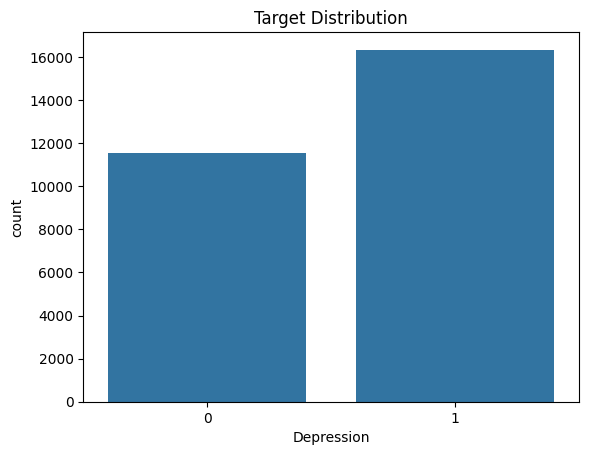

In [23]:
# Target distribution
sns.countplot(x='Depression', data=df)
plt.title('Target Distribution')
plt.show()

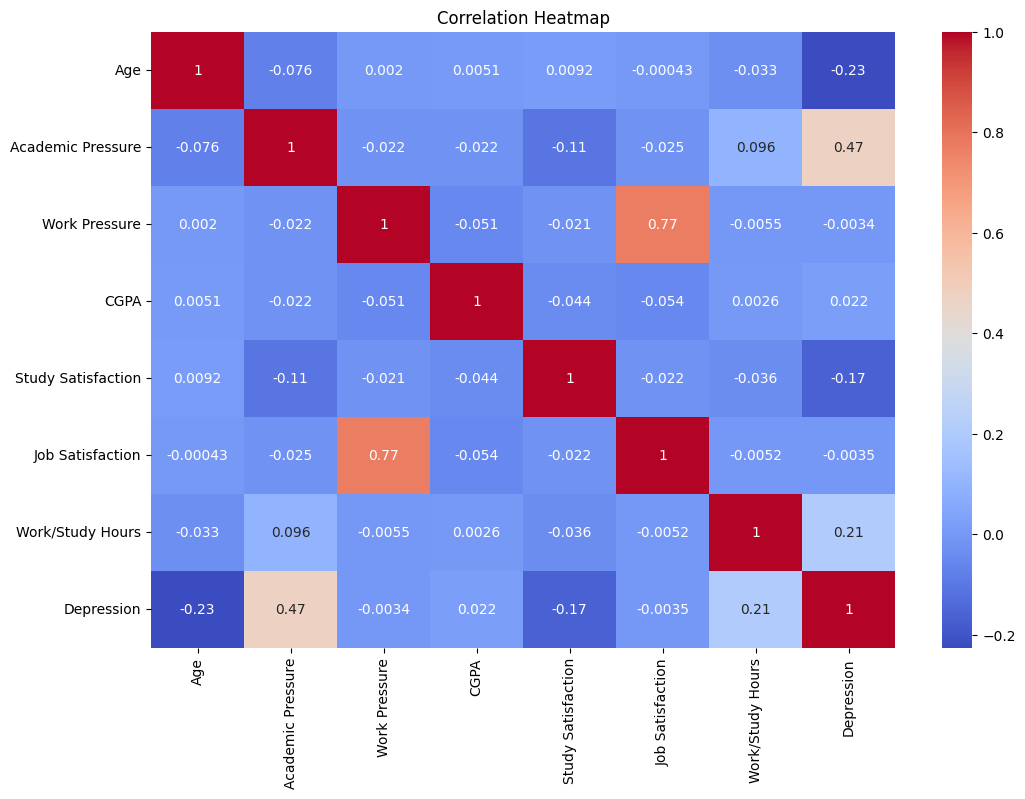

In [24]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

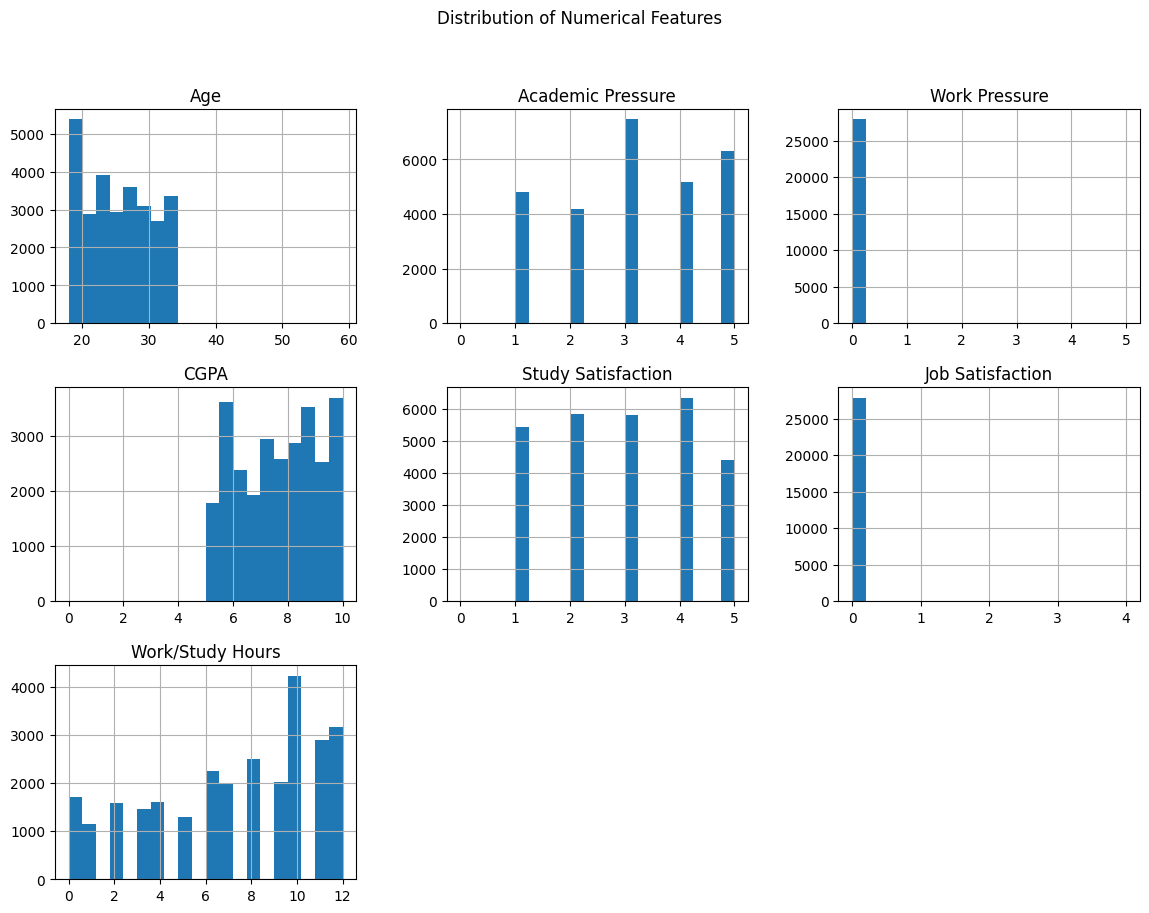

In [25]:
# Histograms for numerical features
numerical_cols = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
                  'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']

df[numerical_cols].hist(bins=20, figsize=(14,10))
plt.suptitle('Distribution of Numerical Features')
plt.show()

/tmp/ipython-input-26-4046147039.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Depression_Status'] = df['Depression'].map({0: 'No', 1: 'Yes'})


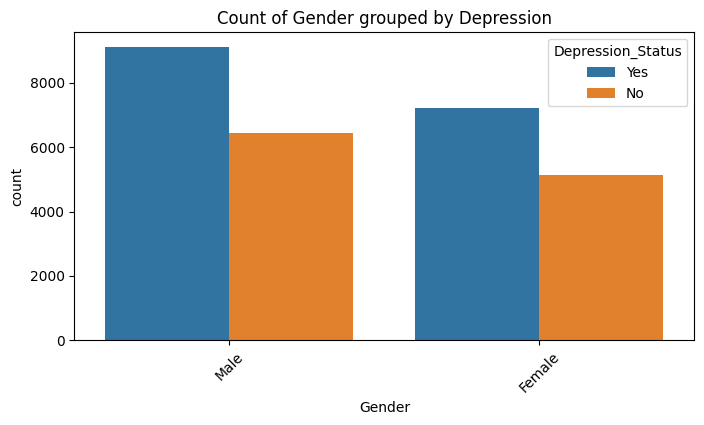

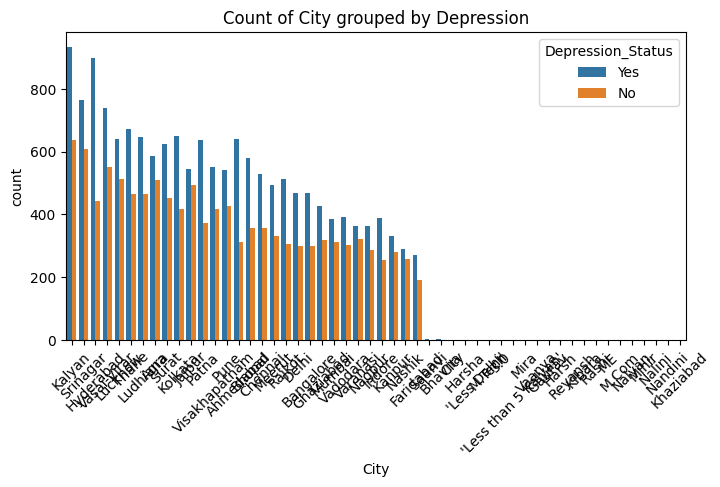

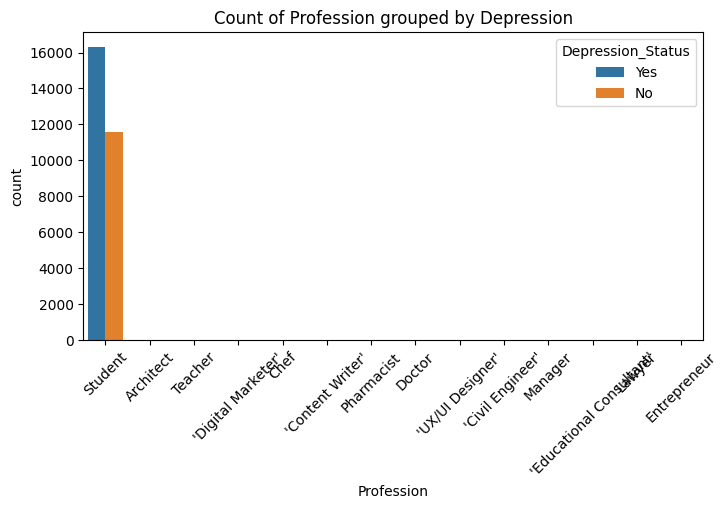

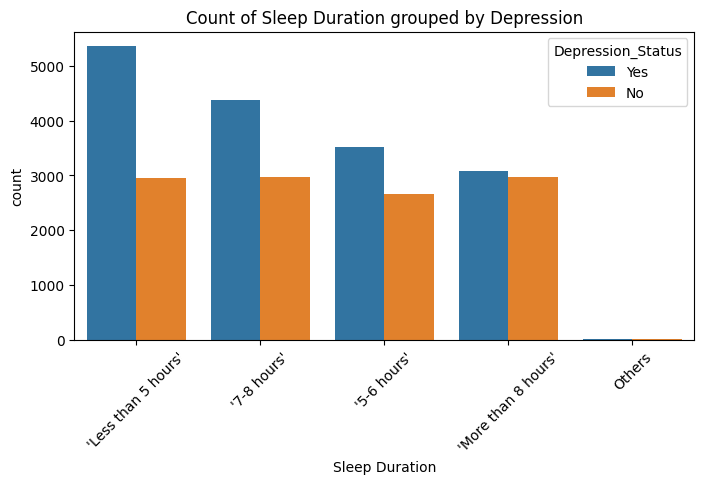

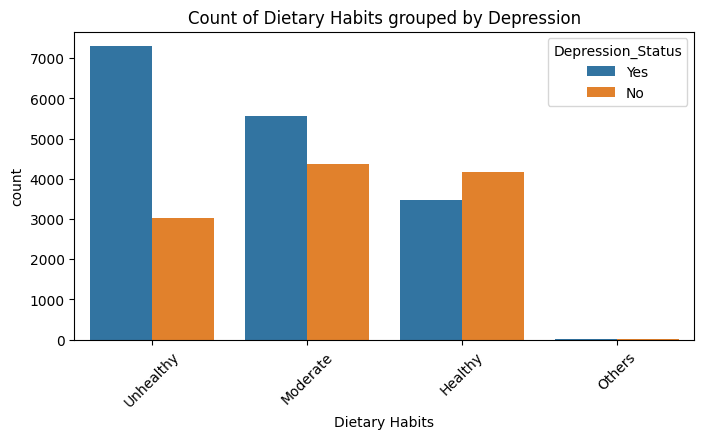

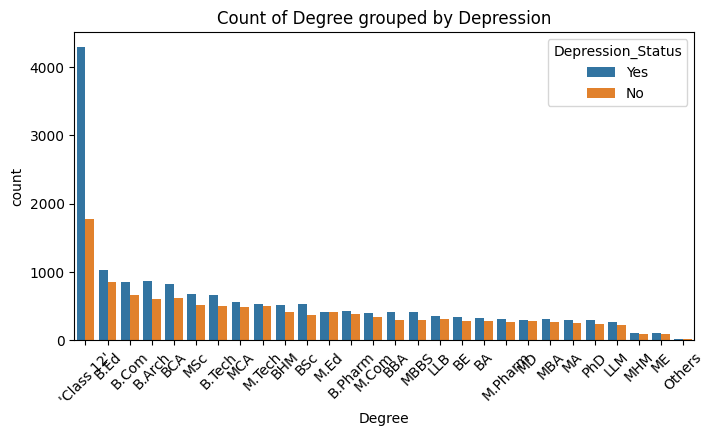

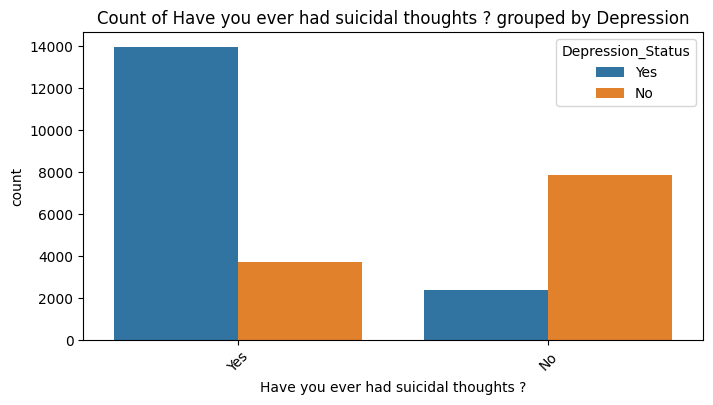

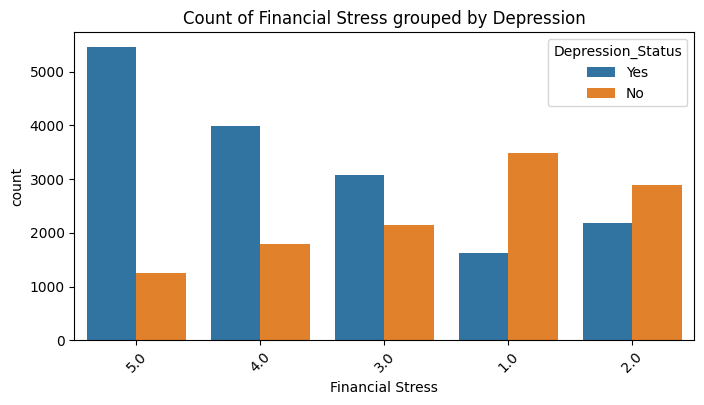

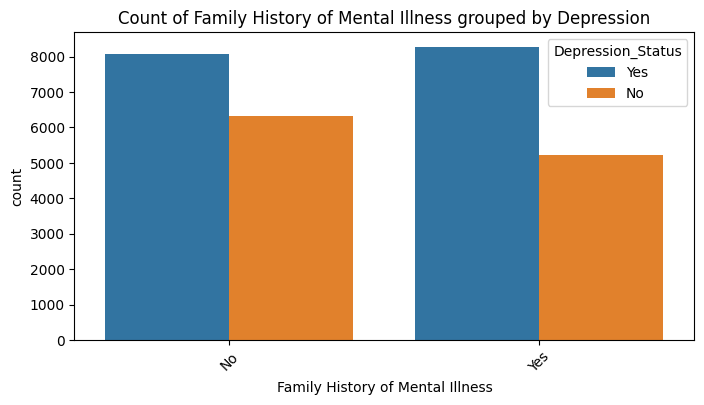

In [26]:
# Count plots for categorical features grouped by Depression
# Mapping for depression 0 → 'No', 1 → 'Yes'
df['Depression_Status'] = df['Depression'].map({0: 'No', 1: 'Yes'})

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='Depression_Status', data=df, order=df[col].value_counts().index)
    plt.title(f'Count of {col} grouped by Depression')
    plt.xticks(rotation=45)
    plt.show()

In [27]:
df_encoded

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Depression,Gender_Male,City_'Less than 5 Kalyan',...,Degree_MHM,Degree_MSc,Degree_Others,Degree_PhD,Have you ever had suicidal thoughts ?_Yes,Financial Stress_2.0,Financial Stress_3.0,Financial Stress_4.0,Financial Stress_5.0,Family History of Mental Illness_Yes
0,33.0,5.0,0.0,8.97,2.0,0.0,3.0,1,True,False,...,False,False,False,False,True,False,False,False,False,False
1,24.0,2.0,0.0,5.90,5.0,0.0,3.0,0,False,False,...,False,False,False,False,False,True,False,False,False,True
2,31.0,3.0,0.0,7.03,5.0,0.0,9.0,0,True,False,...,False,False,False,False,False,False,False,False,False,True
3,28.0,3.0,0.0,5.59,2.0,0.0,4.0,1,False,False,...,False,False,False,False,True,False,False,False,True,True
4,25.0,4.0,0.0,8.13,3.0,0.0,1.0,0,False,False,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,27.0,5.0,0.0,5.75,5.0,0.0,7.0,0,False,False,...,False,False,False,False,True,False,False,False,False,True
27897,27.0,2.0,0.0,9.40,3.0,0.0,0.0,0,True,False,...,False,True,False,False,False,False,True,False,False,True
27898,31.0,3.0,0.0,6.61,4.0,0.0,12.0,0,True,False,...,False,False,False,False,False,True,False,False,False,False
27899,18.0,5.0,0.0,6.88,2.0,0.0,10.0,1,False,False,...,False,False,False,False,True,False,False,False,True,False


# 5. Modeling & Evaluation

In [43]:
# Split data
X = df_encoded.drop('Depression', axis=1)
y = df_encoded['Depression']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train models
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('XGBoost', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
]

for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred))



Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.78      0.81      2348
           1       0.85      0.90      0.87      3232

    accuracy                           0.85      5580
   macro avg       0.85      0.84      0.84      5580
weighted avg       0.85      0.85      0.84      5580


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.76      0.80      2348
           1       0.84      0.90      0.87      3232

    accuracy                           0.84      5580
   macro avg       0.84      0.83      0.83      5580
weighted avg       0.84      0.84      0.84      5580


Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.72      0.73      2348
           1       0.80      0.82      0.81      3232

    accuracy                           0.78      5580
   macro

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [11:58:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.77      0.80      2348
           1       0.84      0.89      0.87      3232

    accuracy                           0.84      5580
   macro avg       0.84      0.83      0.83      5580
weighted avg       0.84      0.84      0.84      5580



<Figure size 400x400 with 0 Axes>

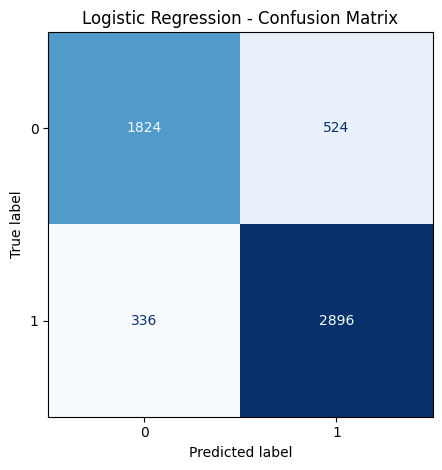

<Figure size 400x400 with 0 Axes>

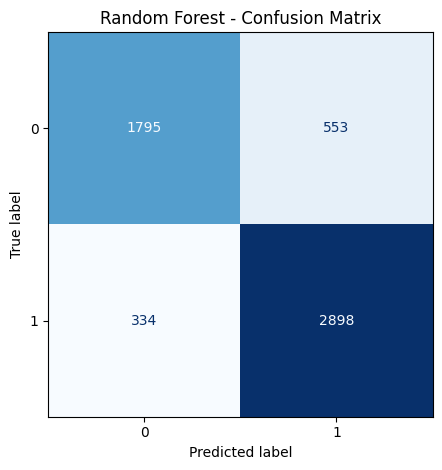

<Figure size 400x400 with 0 Axes>

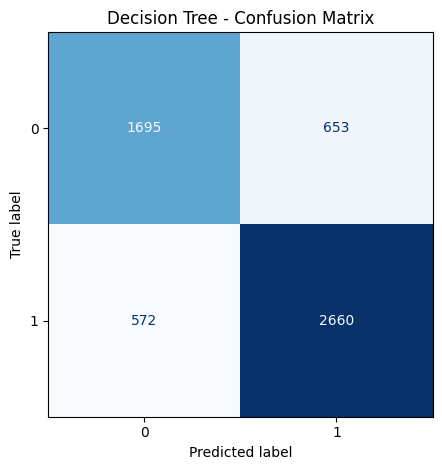

<Figure size 400x400 with 0 Axes>

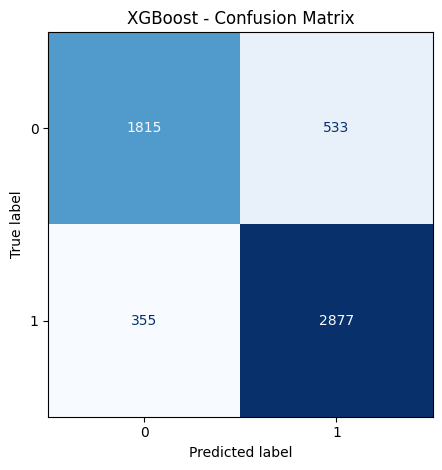

In [44]:
# Plot confusion matrix for each model
for name, model in models:
    y_pred = model.predict(X_test)
    plt.figure(figsize=(4,4))
    disp = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues', colorbar=False)
    plt.title(f'{name} - Confusion Matrix')
    plt.tight_layout()
    plt.show()

                 Model  Accuracy
0  Logistic Regression  0.845878
1        Random Forest  0.841039
2        Decision Tree  0.780466
3              XGBoost  0.840860


/tmp/ipython-input-45-788607440.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')


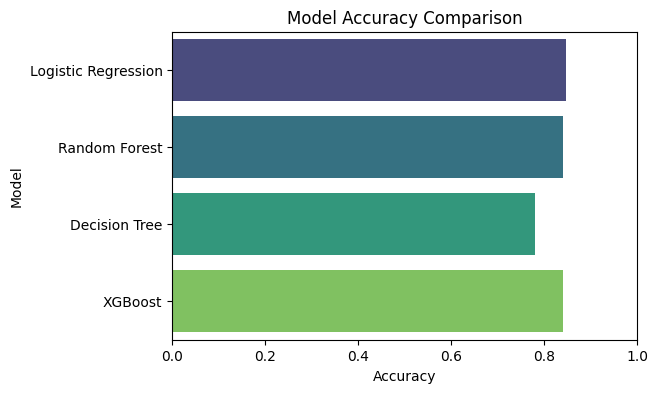

In [45]:
# Accuracy comparison of all models
accuracy_results = []

for name, model in models:
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_results.append((name, acc))

accuracy_df = pd.DataFrame(accuracy_results, columns=['Model', 'Accuracy'])
print(accuracy_df)

# plot as bar chart
plt.figure(figsize=(6,4))
sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlim(0,1)
plt.show()

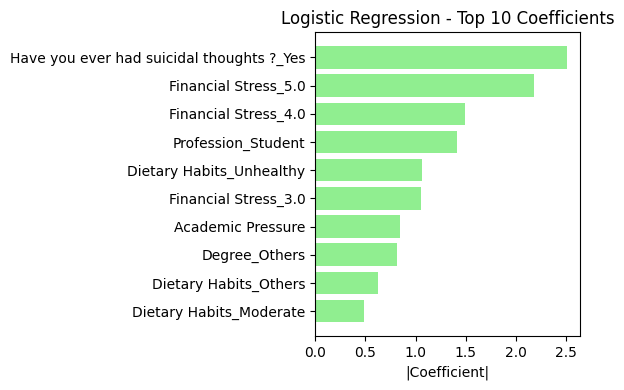

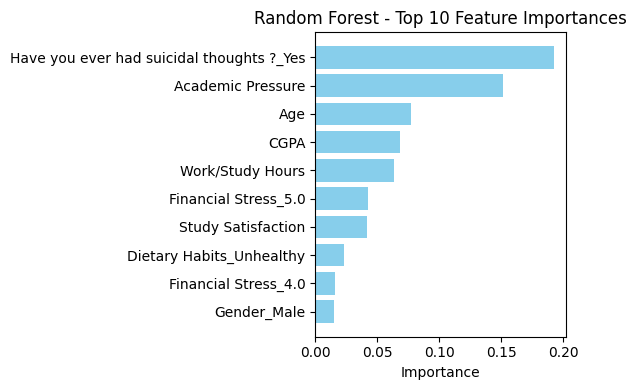

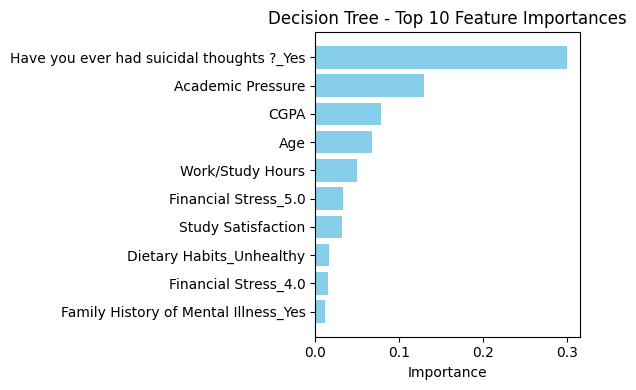

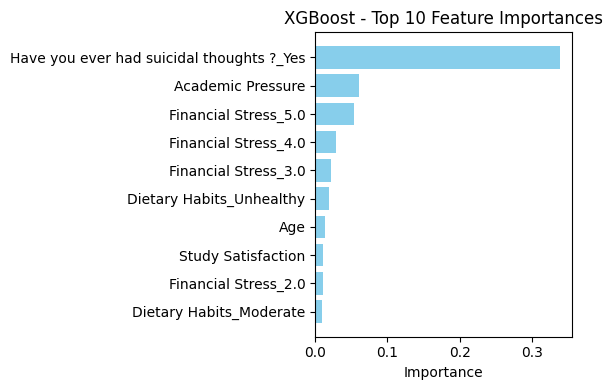

In [46]:
# Plot top 10 feature importance (or coefficients) for each model
for name, model in models:
    if hasattr(model, 'feature_importances_'):
        # Tree-based models
        importance = model.feature_importances_
        top_indices = np.argsort(importance)[-10:]
        plt.figure(figsize=(6,4))
        plt.barh(range(10), importance[top_indices], color='skyblue')
        plt.yticks(range(10), [X.columns[i] for i in top_indices])
        plt.title(f'{name} - Top 10 Feature Importances')
        plt.xlabel('Importance')
        plt.tight_layout()
        plt.show()

    elif hasattr(model, 'coef_'):
        # Logistic Regression
        coef = np.abs(model.coef_[0])
        top_indices = np.argsort(coef)[-10:]
        plt.figure(figsize=(6,4))
        plt.barh(range(10), coef[top_indices], color='lightgreen')
        plt.yticks(range(10), [X.columns[i] for i in top_indices])
        plt.title(f'{name} - Top 10 Coefficients')
        plt.xlabel('|Coefficient|')
        plt.tight_layout()
        plt.show()


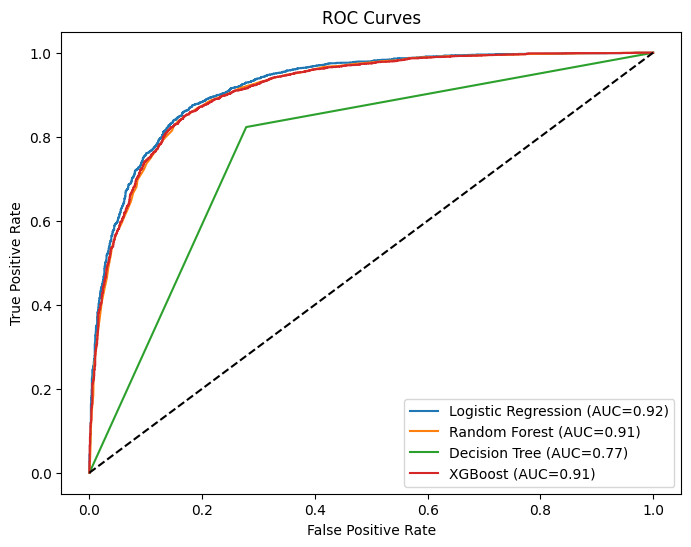

In [36]:
# ROC Curves
plt.figure(figsize=(8,6))
for name, model in models:
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()